# CIFAR-10 results: baseline CNN vs residual CNN

This notebook evaluates the two finished training runs. Train them first:

```
python -m cifar10.train --model baseline --run-name baseline
python -m cifar10.train --model resnet --run-name resnet
```

It covers the evaluation requirements of the brief (loss and accuracy curves, test accuracy, misclassified test images), the Part 2 comparison, and ONNX inference. The test set is used here and nowhere else.

In [1]:
import json
import os
from pathlib import Path

# Run from the repository root so relative paths match the CLI.
if Path.cwd().name == "notebooks":
    os.chdir("..")

import torch
from IPython.display import Image, Markdown, display

from cifar10.checkpoint import load_checkpoint
from cifar10.compare import comparison_rows, to_markdown
from cifar10.config import TrainConfig
from cifar10.data import build_dataloaders
from cifar10.evaluate import evaluate_model
from cifar10.models import build_model
from cifar10.utils import get_device, seed_everything
from cifar10.visualize import plot_comparison, plot_history

RUNS = {"baseline": Path("outputs/baseline"), "resnet": Path("outputs/resnet")}
seed_everything(42)
device = get_device()
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.14.0


## Training setup

Both runs share every setting except `model`.

In [2]:
configs = {name: json.loads((d / "config.json").read_text()) for name, d in RUNS.items()}
differences = {k for k in configs["baseline"] if configs["baseline"][k] != configs["resnet"][k]}
print("settings that differ:", sorted(differences))
print(json.dumps(configs["baseline"], indent=2))

settings that differ: ['model', 'run_name']
{
  "model": "baseline",
  "epochs": 30,
  "batch_size": 128,
  "max_lr": 0.1,
  "momentum": 0.9,
  "weight_decay": 0.0005,
  "dropout": 0.3,
  "label_smoothing": 0.0,
  "val_size": 5000,
  "seed": 42,
  "num_workers": 4,
  "amp": false,
  "device": "auto",
  "data_dir": "data",
  "output_dir": "outputs",
  "run_name": "baseline"
}


## Loss and accuracy curves

Train accuracy is measured on augmented images with dropout active, so it sits below validation accuracy for most of training.

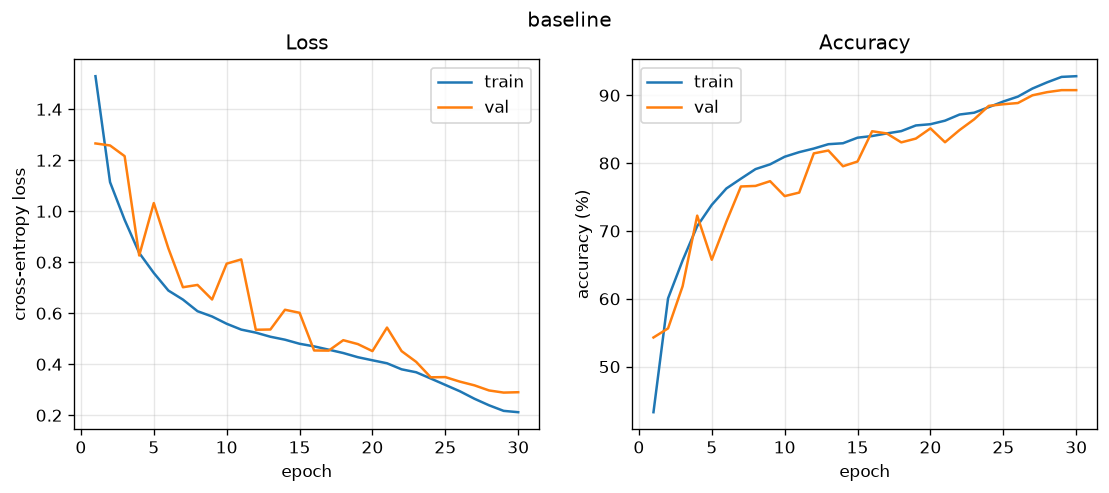

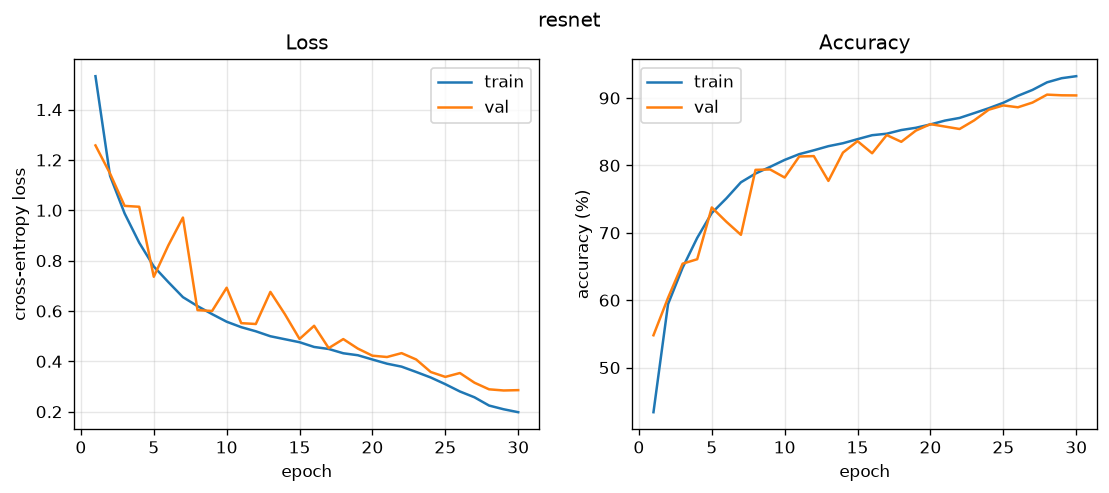

In [3]:
histories = {name: json.loads((d / "history.json").read_text()) for name, d in RUNS.items()}
for name, d in RUNS.items():
    plot_history(histories[name], d / "curves.png", title=name)
    display(Image(str(d / "curves.png")))

## Test accuracy

Each model is restored from `best.pt`, the epoch with the highest validation accuracy, and evaluated once on the 10,000 test images.

In [4]:
metrics = {}
for name, d in RUNS.items():
    state = torch.load(d / "best.pt", map_location="cpu", weights_only=True)
    config = TrainConfig.from_dict(state["config"])
    model = build_model(config.model, dropout=config.dropout)
    load_checkpoint(d / "best.pt", model)
    _, _, test_loader = build_dataloaders(config.data_dir, config.batch_size, config.val_size,
                                          config.seed, num_workers=2)
    metrics[name] = evaluate_model(model, test_loader, device, d)
    print(f"{name:<9} best epoch {state['epoch']:>2} | val acc {state['best_val_acc']:.2%} | "
          f"test acc {metrics[name]['test_acc']:.2%} | test loss {metrics[name]['test_loss']:.4f}")

baseline  best epoch 29 | val acc 90.76% | test acc 89.88% | test loss 0.3045


resnet    best epoch 28 | val acc 90.50% | test acc 89.85% | test loss 0.3129


### Per-class test accuracy

In [5]:
classes = list(metrics["baseline"]["per_class_acc"])
rows = ["| Class | Baseline | Residual | Change |", "|---|---:|---:|---:|"]
for c in classes:
    b, r = metrics["baseline"]["per_class_acc"][c], metrics["resnet"]["per_class_acc"][c]
    rows.append(f"| {c} | {b:.1%} | {r:.1%} | {100 * (r - b):+.1f} pt |")
display(Markdown("\n".join(rows)))

| Class | Baseline | Residual | Change |
|---|---:|---:|---:|
| airplane | 91.6% | 91.9% | +0.3 pt |
| automobile | 96.2% | 94.5% | -1.7 pt |
| bird | 85.7% | 84.3% | -1.4 pt |
| cat | 79.5% | 80.4% | +0.9 pt |
| deer | 90.3% | 90.4% | +0.1 pt |
| dog | 83.8% | 82.2% | -1.6 pt |
| frog | 93.0% | 92.8% | -0.2 pt |
| horse | 91.4% | 92.0% | +0.6 pt |
| ship | 94.1% | 95.5% | +1.4 pt |
| truck | 93.2% | 94.5% | +1.3 pt |

### Confusion matrices

baseline


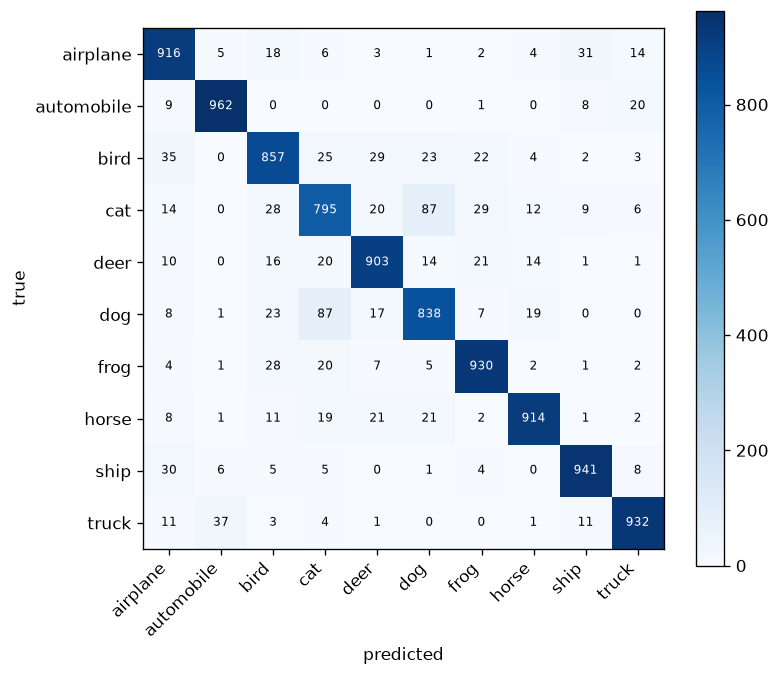

resnet


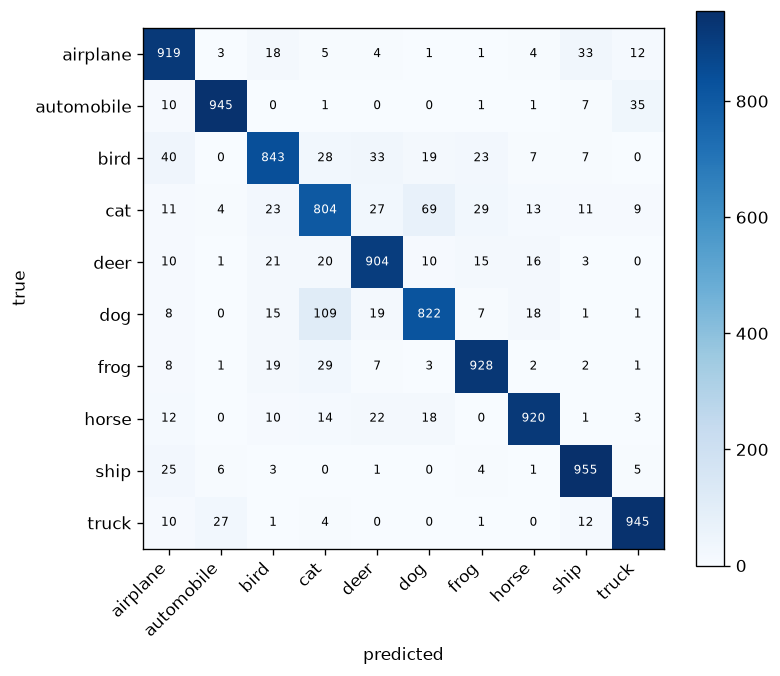

In [6]:
for name, d in RUNS.items():
    print(name)
    display(Image(str(d / "confusion_matrix.png")))

## Misclassified test images

The first 32 test images each model gets wrong, with the true label, the predicted label and the model's confidence in its prediction.

baseline


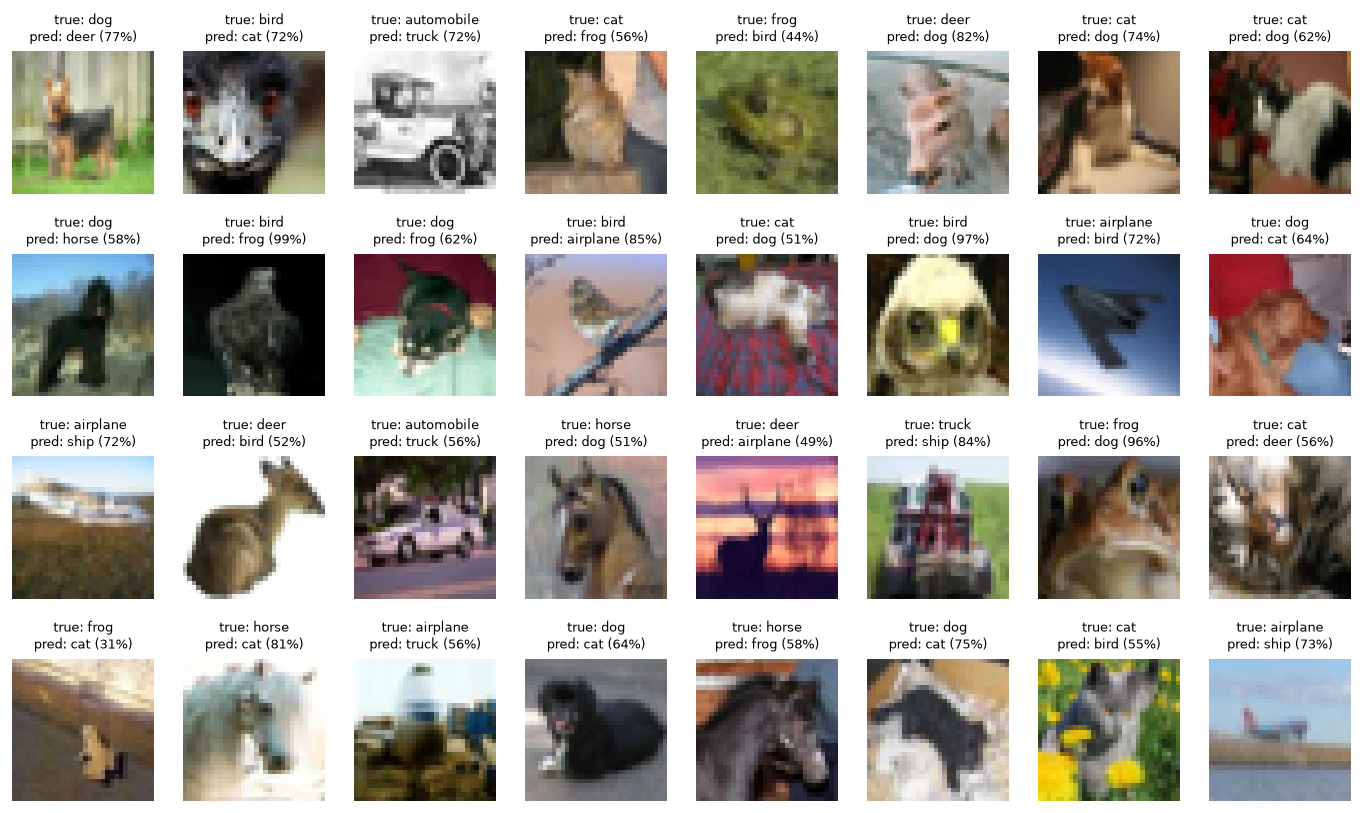

resnet


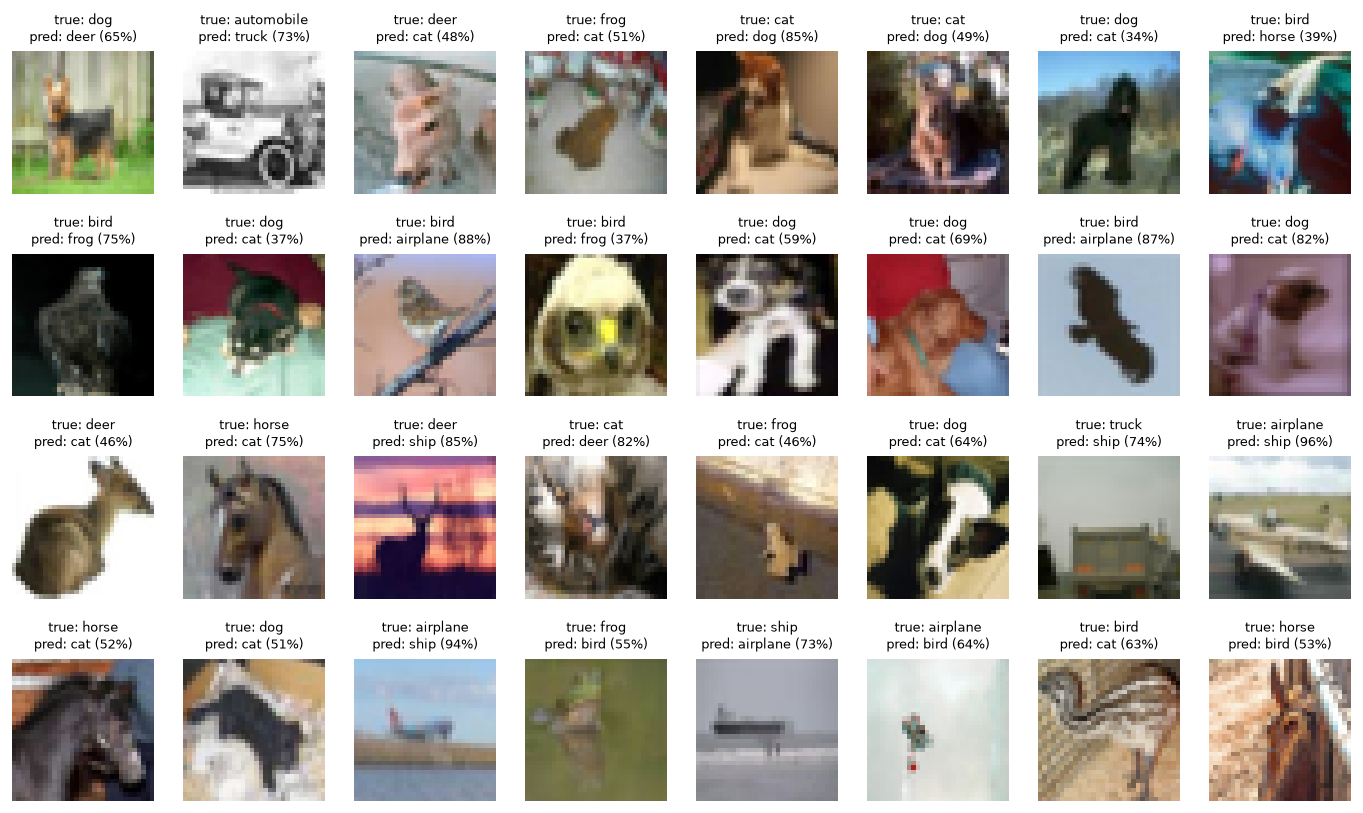

In [7]:
for name, d in RUNS.items():
    print(name)
    display(Image(str(d / "misclassified.png")))

## Baseline vs residual (Part 2)

| Run | Model | Parameters | Epochs | Best val acc | Test acc | Test loss | s/epoch |
|---|---|---:|---:|---:|---:|---:|---:|
| baseline | baseline | 288,746 | 30 | 90.76% | 89.88% | 0.3045 | 27.3 |
| resnet | resnet | 299,530 | 30 | 90.50% | 89.85% | 0.3129 | 27.1 |


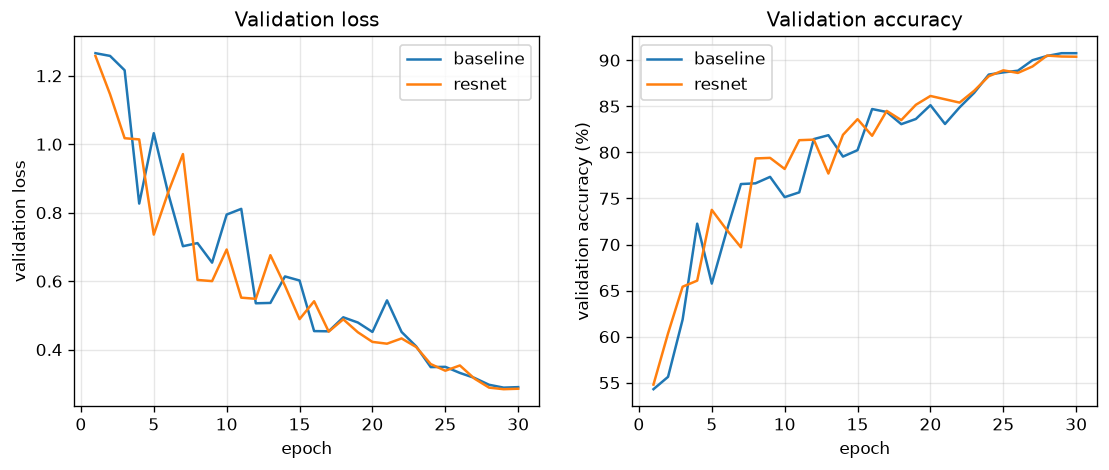

In [8]:
out = Path("outputs/comparison")
out.mkdir(parents=True, exist_ok=True)
table = to_markdown(comparison_rows(list(RUNS.values())))
(out / "comparison.md").write_text(table)
plot_comparison(histories, out / "validation_curves.png")
display(Markdown(table))
display(Image(str(out / "validation_curves.png")))

### How fast each model trains

Final accuracy hides what happens during training. These numbers come from the validation curves above: the epoch at which each model first passes a given accuracy, and its average accuracy over the first half of training.

In [9]:
def first_epoch_at(history, threshold):
    return next((i + 1 for i, acc in enumerate(history["val_acc"]) if acc >= threshold), None)

rows = ["| Metric | Baseline | Residual |", "|---|---:|---:|"]
for threshold in (0.70, 0.80, 0.85, 0.88):
    b, r = (first_epoch_at(histories[n], threshold) for n in ("baseline", "resnet"))
    rows.append(f"| First epoch at {threshold:.0%} validation accuracy | {b} | {r} |")
b_mean = sum(histories["baseline"]["val_acc"][:15]) / 15
r_mean = sum(histories["resnet"]["val_acc"][:15]) / 15
rows.append(f"| Mean validation accuracy, epochs 1-15 | {b_mean:.2%} | {r_mean:.2%} |")
display(Markdown("\n".join(rows)))

| Metric | Baseline | Residual |
|---|---:|---:|
| First epoch at 70% validation accuracy | 4 | 5 |
| First epoch at 80% validation accuracy | 12 | 11 |
| First epoch at 85% validation accuracy | 20 | 19 |
| First epoch at 88% validation accuracy | 24 | 24 |
| Mean validation accuracy, epochs 1-15 | 72.37% | 73.64% |

### Is the difference larger than the noise?

A single run cannot tell a real improvement from random variation. Both models were trained a second time with seed 43 and nothing else changed. The spread between two seeds of the same model sets the floor: any gap between models smaller than that means nothing.

In [10]:
seed_runs = [Path(f"outputs/{name}{suffix}") for suffix in ("", "-s43") for name in ("baseline", "resnet")]
if all((d / "test_metrics.json").exists() for d in seed_runs):
    seed_rows = comparison_rows(seed_runs)
    seed_table = to_markdown(seed_rows)
    (out / "seeds.md").write_text(seed_table)
    display(Markdown(seed_table))
    by_model = {}
    for row in seed_rows:
        by_model.setdefault(row["model"], []).append(row["test_acc"])
    for model, accs in by_model.items():
        print(f"{model:<9} test accuracy across seeds: "
              + ", ".join(f"{a:.2%}" for a in accs)
              + f" | spread {100 * (max(accs) - min(accs)):.2f} pt")
    gap = sum(by_model["resnet"]) / 2 - sum(by_model["baseline"]) / 2
    print(f"mean residual minus mean baseline: {100 * gap:+.2f} pt")
else:
    print("Second-seed runs not found. Create them with: scripts/train_all.sh 43")

| Run | Model | Parameters | Epochs | Best val acc | Test acc | Test loss | s/epoch |
|---|---|---:|---:|---:|---:|---:|---:|
| baseline | baseline | 288,746 | 30 | 90.76% | 89.88% | 0.3045 | 27.3 |
| resnet | resnet | 299,530 | 30 | 90.50% | 89.85% | 0.3129 | 27.1 |
| baseline-s43 | baseline | 288,746 | 30 | 90.68% | 89.91% | 0.3068 | 20.8 |
| resnet-s43 | resnet | 299,530 | 30 | 90.88% | 89.98% | 0.3011 | 27.0 |


baseline  test accuracy across seeds: 89.88%, 89.91% | spread 0.03 pt
resnet    test accuracy across seeds: 89.85%, 89.98% | spread 0.13 pt
mean residual minus mean baseline: +0.02 pt


## ONNX export and inference

Export the residual model and check that ONNX Runtime reproduces the PyTorch logits on test images.

In [11]:
import numpy as np
import onnxruntime as ort

from cifar10.export_onnx import export_to_onnx

state = torch.load(RUNS["resnet"] / "best.pt", map_location="cpu", weights_only=True)
model = build_model("resnet", dropout=state["config"]["dropout"])
load_checkpoint(RUNS["resnet"] / "best.pt", model)
onnx_path = export_to_onnx(model, RUNS["resnet"] / "model.onnx")

images, labels = next(iter(test_loader))
with torch.no_grad():
    torch_logits = model.eval()(images).numpy()
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
[onnx_logits] = session.run(None, {session.get_inputs()[0].name: images.numpy()})
print(f"{len(images)} images | max |logit diff| {np.abs(onnx_logits - torch_logits).max():.2e} | "
      f"prediction agreement {(onnx_logits.argmax(1) == torch_logits.argmax(1)).mean():.2%} | "
      f"ONNX accuracy {(onnx_logits.argmax(1) == labels.numpy()).mean():.2%}")

[torch.onnx] Obtain model graph for `ResidualCNN([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `ResidualCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


256 images | max |logit diff| 3.24e-05 | prediction agreement 100.00% | ONNX accuracy 91.02%


## Conclusion

**Test accuracy, 30 epochs, two seeds each**

| Model | Seed 42 | Seed 43 | Mean |
|---|---:|---:|---:|
| Baseline CNN (288,746 parameters) | 89.88% | 89.91% | 89.90% |
| Residual CNN (299,530 parameters) | 89.85% | 89.98% | 89.92% |

The residual model ends 0.02 points ahead on average. Two seeds of the same
model differ by 0.03 points (baseline) and 0.13 points (residual), so the gap
between the architectures is smaller than the noise between reruns of either
one. On this network, at this depth, the skip connections buy no accuracy.

One difference does hold across both seeds: the residual model is ahead during
the first half of training. Its mean validation accuracy over epochs 1 to 15 is
73.6% against 72.4% for seed 42, and 74.1% against 72.2% for seed 43. The
shortcuts help the optimizer early, and the baseline catches up once the
learning rate comes down.

This matches what residual connections are for. They were introduced to make
networks of 50 and 100 layers trainable at all. Six convolutional layers with
BatchNorm train without help, so there is no degradation left to fix. Showing a
clear gain would need a deeper network, which would also change depth, width
and parameter count at once and break the like-for-like comparison this run was
designed around (see docs/decisions/ADR-002-residual-block.md).

The cost of the shortcuts is 10,784 parameters, 3.7% more than the baseline,
with no measurable change in epoch time.